### IMPORT

In [1]:
from pathlib import Path

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader
import rootutils

rootutils.setup_root(Path(".").resolve(), indicator=".project-root", pythonpath=True)

from src.models.bev_emb import BEVAdapter
from src.models.bevqa import BEVQA
from src.data.bevqa_dataset import BEVQADataset
from src.models.head import OutputHead
from src.models.mca import MCALayer
from src.models.text_emb import TextAdapter
from src.training.train import train_epoch, val_epoch
from src.utils.text_utils import decode_question

device = "cuda" if torch.cuda.is_available() else "cpu"

### PATH

In [2]:
ROOT = Path("/home/robesafe-sandra/BEV")
DISK = Path("/media/robesafe-sandra/Datos")
MINI_DIR = DISK / "dataset_mini"
MINI_DICT_DIR = MINI_DIR / "dict_mini"
MINI_FEAT_DIR = MINI_DIR / "bev_features_mini"

GLOVE = ROOT/ "glove.6B/glove.6B.300d.txt"
#hydra 

### DATASET

In [3]:
train_dataset = BEVQADataset(
    bev_dir=MINI_FEAT_DIR / "train_mini",
    json_path=MINI_DICT_DIR / "NuScenes_train_questions_mini.json",
    glove=GLOVE
)

In [4]:
val_dataset = BEVQADataset(
    bev_dir=MINI_FEAT_DIR / "val_mini",
    json_path=MINI_DICT_DIR / "NuScenes_val_questions_mini.json",
    glove=GLOVE
)

In [5]:
feat, quest, ans = train_dataset[0]
print(feat.shape, quest.shape, ans)

torch.Size([128, 200, 200]) torch.Size([35, 300]) tensor(26)


torch.Size([128, 200, 200]) torch.Size([35, 300]) tensor(26)


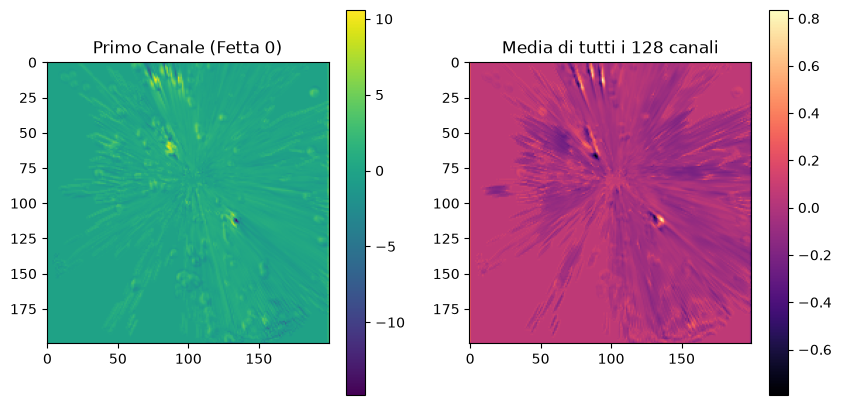

In [6]:
feat, quest, ans = train_dataset[0]
print(feat.shape, quest.shape, ans)

import matplotlib.pyplot as plt
import torch

# Convertiamo in numpy (staccando dal gradiente se necessario)
feat_np = feat.detach().cpu().numpy()

plt.figure(figsize=(10, 5))

# Opzione A: Visualizza il primo canale (indice 0)
plt.subplot(1, 2, 1)
plt.imshow(feat_np[0], cmap='viridis')
plt.title("Primo Canale (Fetta 0)")
plt.colorbar()

# Opzione B: Visualizza la media di tutti i 128 canali
plt.subplot(1, 2, 2)
plt.imshow(feat_np.mean(axis=0), cmap='magma')
plt.title("Media di tutti i 128 canali")
plt.colorbar()

plt.show()

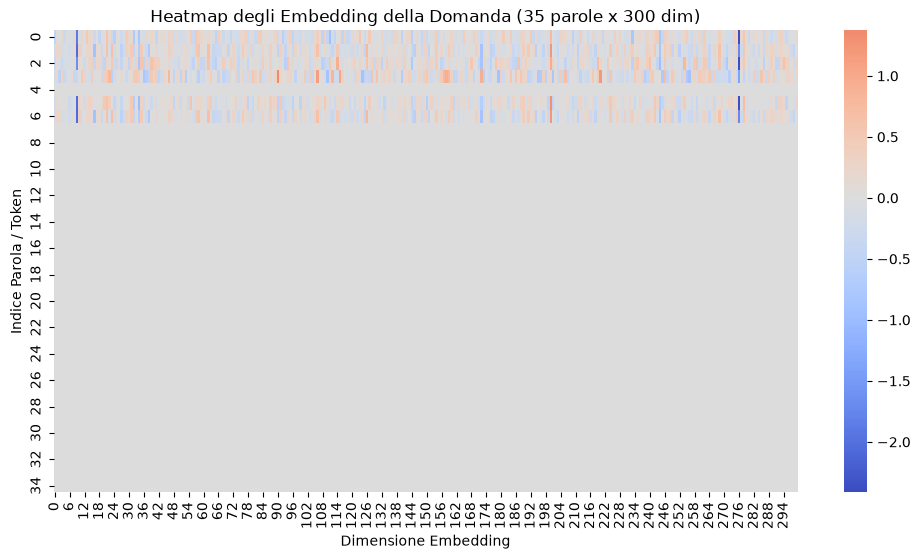

In [9]:
import seaborn as sns

quest_np = quest.detach().cpu().numpy()

plt.figure(figsize=(12, 6))
# Usiamo seaborn per una heatmap pulita
sns.heatmap(quest_np, cmap='coolwarm', center=0)
plt.title("Heatmap degli Embedding della Domanda (35 parole x 300 dim)")
plt.xlabel("Dimensione Embedding")
plt.ylabel("Indice Parola / Token")
plt.show()

In [11]:
# Estraiamo il valore numerico puro dal tensore
risposta_id = ans.item()

print(f"ID della Risposta: {risposta_id}")

# Se hai una lista/dizionario di parole del vocabolario (es. vocab), puoi fare:
# print(f"Parola corrispondente: {vocab[risposta_id]}")

ID della Risposta: 26


### DATALOADER

In [12]:
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [13]:
feat, quest, ans = next(iter(train_dataloader))
print(feat.shape, quest.shape, ans)

torch.Size([4, 128, 200, 200]) torch.Size([4, 35, 300]) tensor([ 1, 12, 29, 18])


### EMBEDDINGS

In [14]:
text_output = nn.Linear(300,512)(quest)
text_output.shape

torch.Size([4, 35, 512])

In [15]:
feat_output = nn.AdaptiveAvgPool2d((20, 20))(feat)
feat_output = feat_output.flatten(2).transpose(1, 2)
feat_output = nn.Linear(128, 512)(feat_output)
feat_output.shape

torch.Size([4, 400, 512])

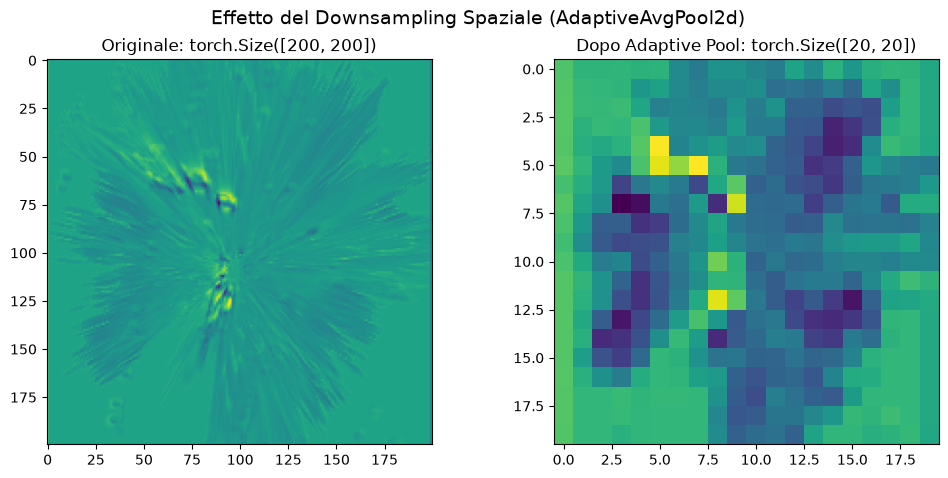

--------------------------------------------------------------------------------
Shape intermedia dopo flatten e transpose: torch.Size([4, 400, 128])
--------------------------------------------------------------------------------


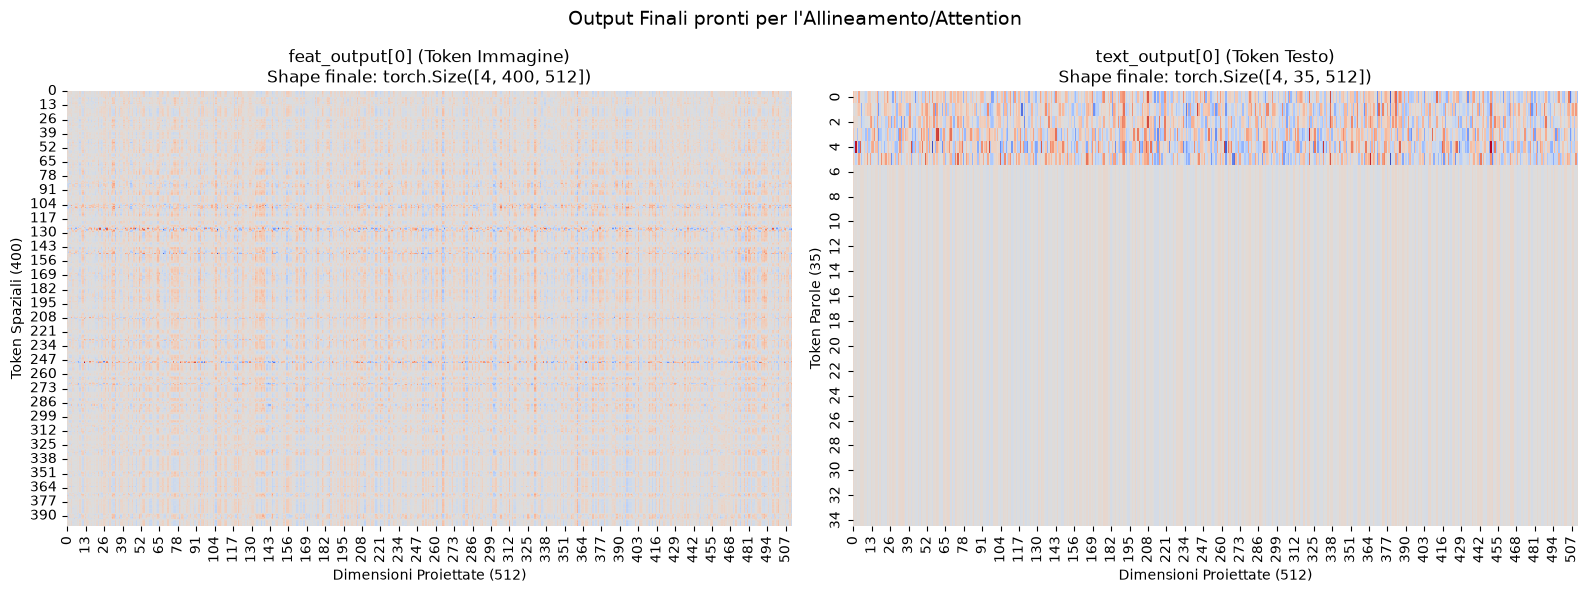

In [16]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Ipotizziamo che tu abbia già estratto feat e quest dal dataloader
# Definiamo i layer come nel tuo codice
pool = nn.AdaptiveAvgPool2d((20, 20))
linear_feat = nn.Linear(128, 512)
linear_text = nn.Linear(300, 512)

# ---- ELABORAZIONE FEAT ----
feat_pooled = pool(feat)
feat_flat = feat_pooled.flatten(2).transpose(1, 2)
with torch.no_grad():
    feat_output = linear_feat(feat_flat)

# ---- ELABORAZIONE TEXT ----
with torch.no_grad():
    text_output = linear_text(quest)

# ==========================================
# VISUALIZZAZIONE NEL NOTEBOOK
# ==========================================

# 1. Visualizziamo l'effetto del Pooling (prendiamo il primo elemento del batch, media dei canali)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(feat[0].detach().cpu().numpy().mean(axis=0), cmap='viridis')
axes[0].set_title(f"Originale: {feat.shape[2:]}")

axes[1].imshow(feat_pooled[0].detach().cpu().numpy().mean(axis=0), cmap='viridis')
axes[1].set_title(f"Dopo Adaptive Pool: {feat_pooled.shape[2:]}")
plt.suptitle("Effetto del Downsampling Spaziale (AdaptiveAvgPool2d)", fontsize=14)
plt.show()

print("-" * 80)
print(f"Shape intermedia dopo flatten e transpose: {feat_flat.shape}")
print("-" * 80)

# 2. Visualizziamo gli output finali proiettati a 512 dimensioni
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Selezioniamo il primo elemento del batch [0] per la visualizzazione
sns.heatmap(feat_output[0].detach().cpu().numpy(), cmap='coolwarm', ax=axes[0], cbar=False)
axes[0].set_title(f"feat_output[0] (Token Immagine)\nShape finale: {feat_output.shape}")
axes[0].set_ylabel("Token Spaziali (400)")
axes[0].set_xlabel("Dimensioni Proiettate (512)")

sns.heatmap(text_output[0].detach().cpu().numpy(), cmap='coolwarm', ax=axes[1], cbar=False)
axes[1].set_title(f"text_output[0] (Token Testo)\nShape finale: {text_output.shape}")
axes[1].set_ylabel("Token Parole (35)")
axes[1].set_xlabel("Dimensioni Proiettate (512)")

plt.suptitle("Output Finali pronti per l'Allineamento/Attention", fontsize=14)
plt.tight_layout()
plt.show()

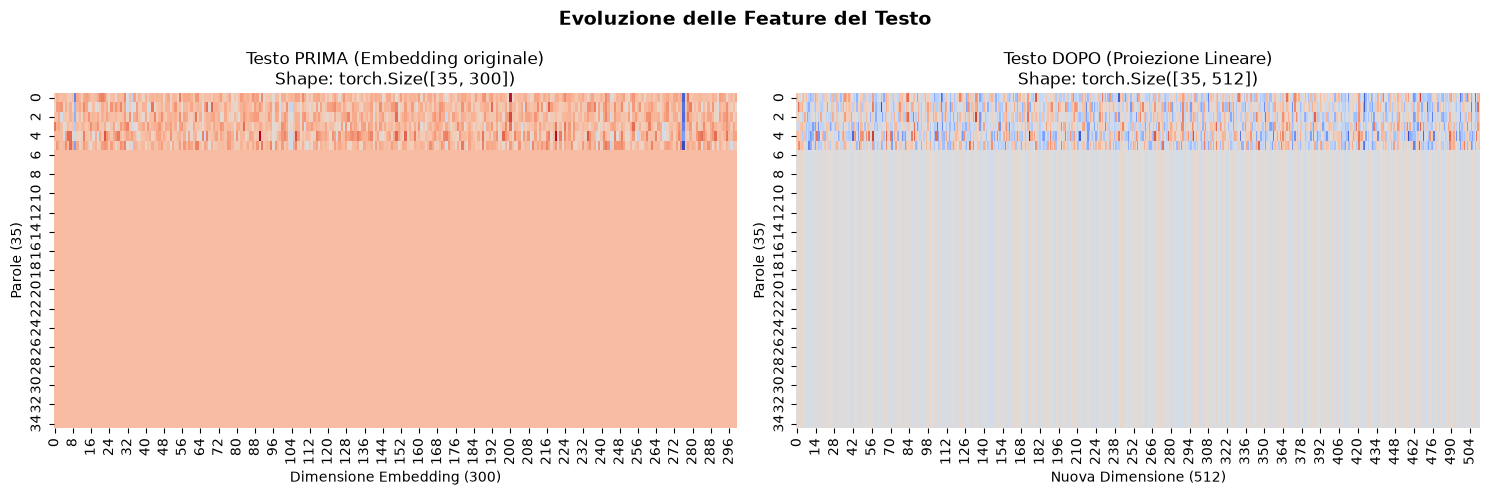

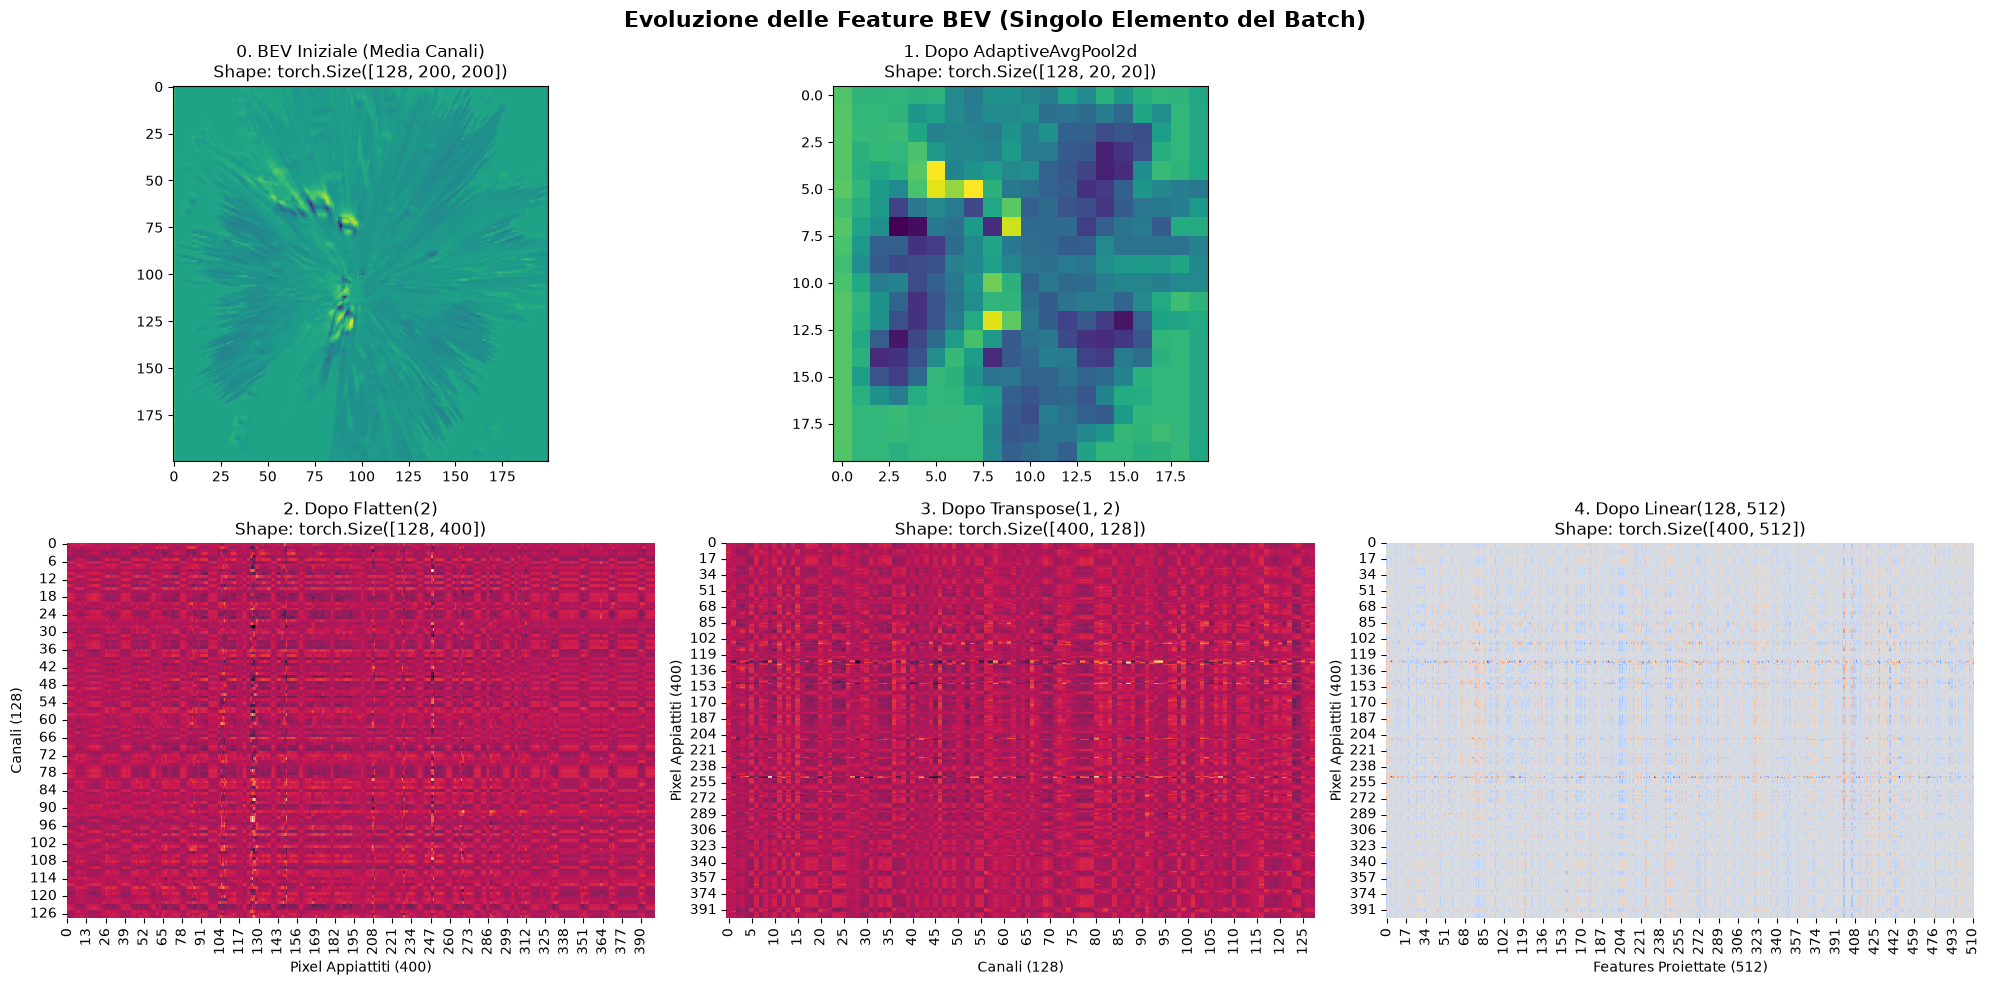

In [17]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione dei layer (come nel tuo modello)
pool = nn.AdaptiveAvgPool2d((20, 20))
linear_feat = nn.Linear(128, 512)
linear_text = nn.Linear(300, 512)

# Svolgiamo i passaggi mantenendo traccia di ogni shape intermedia
# ------------------------------------
# 1. TRASFORMAZIONE TESTO
# ------------------------------------
quest_iniziale = quest[0] # Selezioniamo il primo elemento del batch

with torch.no_grad():
    text_output_all = linear_text(quest)
    text_output_finale = text_output_all[0]

# ------------------------------------
# 2. TRASFORMAZIONE BEV (PASSO DOPO PASSO)
# ------------------------------------
# Step 0: Iniziale
feat_iniziale = feat[0] 

# Step 1: Adaptive Avg Pool
feat_pooled_all = pool(feat)
feat_pooled = feat_pooled_all[0]

# Step 2: Flatten
feat_flattened_all = feat_pooled_all.flatten(2)
feat_flattened = feat_flattened_all[0]

# Step 3: Transpose
feat_transposed_all = feat_flattened_all.transpose(1, 2)
feat_transposed = feat_transposed_all[0]

# Step 4: Linear
with torch.no_grad():
    feat_linear_all = linear_feat(feat_transposed_all)
    feat_linear = feat_linear_all[0]


# =====================================================================
# VISUALIZZAZIONE 1: TESTO (PRIMA E DOPO)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Prima della proiezione lineare
sns.heatmap(quest_iniziale.detach().cpu().numpy(), cmap='coolwarm', ax=axes[0], cbar=False)
axes[0].set_title(f"Testo PRIMA (Embedding originale)\nShape: {quest_iniziale.shape}")
axes[0].set_ylabel("Parole (35)")
axes[0].set_xlabel("Dimensione Embedding (300)")

# Dopo la proiezione lineare
sns.heatmap(text_output_finale.detach().cpu().numpy(), cmap='coolwarm', ax=axes[1], cbar=False)
axes[1].set_title(f"Testo DOPO (Proiezione Lineare)\nShape: {text_output_finale.shape}")
axes[1].set_ylabel("Parole (35)")
axes[1].set_xlabel("Nuova Dimensione (512)")

plt.suptitle("Evoluzione delle Feature del Testo", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# =====================================================================
# VISUALIZZAZIONE 2: FEAT BEV (PIPELINE PASSO DOPO PASSO)
# =====================================================================
# Creiamo un plot multi-pannello per seguire la metamorfosi della BEV
fig = plt.figure(figsize=(20, 10))

# Step 0: BEV Iniziale (Media dei canali per vederla come immagine)
ax0 = plt.subplot(2, 3, 1)
ax0.imshow(feat_iniziale.detach().cpu().numpy().mean(axis=0), cmap='viridis')
ax0.set_title(f"0. BEV Iniziale (Media Canali)\nShape: {feat_iniziale.shape}")

# Step 1: Dopo AdaptiveAvgPool2d
ax1 = plt.subplot(2, 3, 2)
ax1.imshow(feat_pooled.detach().cpu().numpy().mean(axis=0), cmap='viridis')
ax1.set_title(f"1. Dopo AdaptiveAvgPool2d\nShape: {feat_pooled.shape}")

# Step 2: Dopo Flatten
ax2 = plt.subplot(2, 3, 4)
sns.heatmap(feat_flattened.detach().cpu().numpy(), cmap='rocket', ax=ax2, cbar=False)
ax2.set_title(f"2. Dopo Flatten(2)\nShape: {feat_flattened.shape}")
ax2.set_ylabel("Canali (128)")
ax2.set_xlabel("Pixel Appiattiti (400)")

# Step 3: Dopo Transpose
ax3 = plt.subplot(2, 3, 5)
sns.heatmap(feat_transposed.detach().cpu().numpy(), cmap='rocket', ax=ax3, cbar=False)
ax3.set_title(f"3. Dopo Transpose(1, 2)\nShape: {feat_transposed.shape}")
ax3.set_ylabel("Pixel Appiattiti (400)")
ax3.set_xlabel("Canali (128)")

# Step 4: Dopo il Linear
ax4 = plt.subplot(2, 3, 6)
sns.heatmap(feat_linear.detach().cpu().numpy(), cmap='coolwarm', ax=ax4, cbar=False)
ax4.set_title(f"4. Dopo Linear(128, 512)\nShape: {feat_linear.shape}")
ax4.set_ylabel("Pixel Appiattiti (400)")
ax4.set_xlabel("Features Proiettate (512)")

plt.suptitle("Evoluzione delle Feature BEV (Singolo Elemento del Batch)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### MCAN

In [23]:
mca = MCALayer()
bev_out, text_out = mca(feat_output, text_output)
print(bev_out.shape, text_out.shape) # [4, 400, 512], [4, 35, 512]

torch.Size([4, 400, 512]) torch.Size([4, 35, 512])


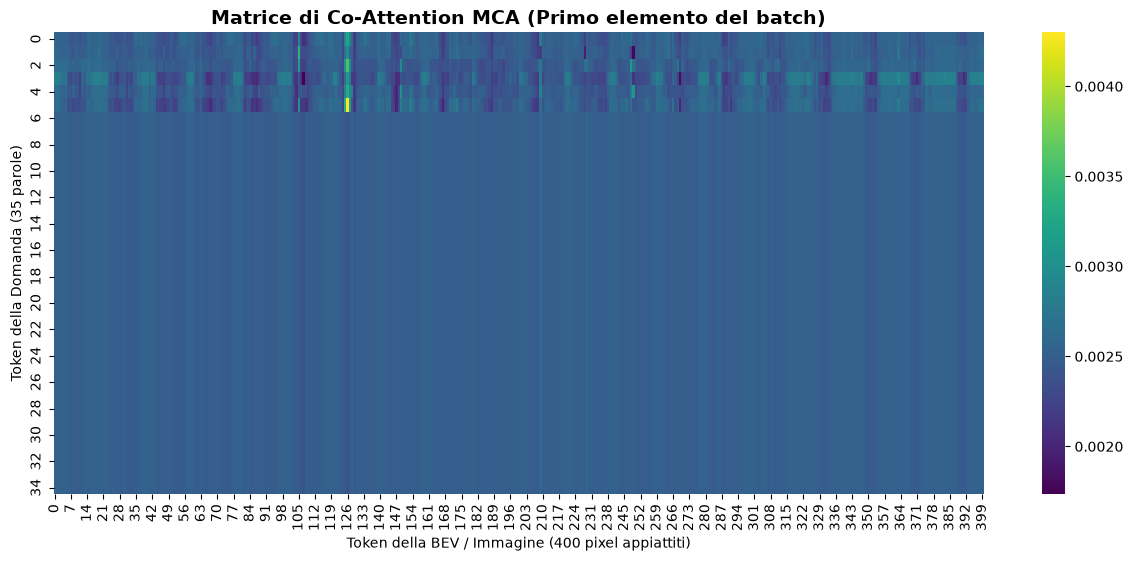

In [18]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Supponiamo che mca(feat_output, text_output) esegua una Cross-Attention.
# Generiamo una matrice di attenzione simulata con la stessa logica di un MCA
# (Softmax del prodotto scalare tra Testo e BEV) per potertela mostrare:
with torch.no_grad():
    # query: testo [4, 35, 512], key: bev [4, 400, 512]
    # Matrice di attenzione risultante: [4, 35, 400]
    scores = torch.bmm(text_output, feat_output.transpose(1, 2)) / (512 ** 0.5)
    attn_matrix = torch.softmax(scores, dim=-1)

# Selezioniamo il primo elemento del batch [0]
attn_singolo = attn_matrix[0].detach().cpu().numpy() # Shape: (35, 400)

# =====================================================================
# VISUALIZZAZIONE 1: La Matrice di Co-Attention (Testo vs BEV)
# =====================================================================
plt.figure(figsize=(15, 6))
sns.heatmap(attn_singolo, cmap='viridis', cbar=True)
plt.title("Matrice di Co-Attention MCA (Primo elemento del batch)", fontsize=14, fontweight='bold')
plt.ylabel("Token della Domanda (35 parole)")
plt.xlabel("Token della BEV / Immagine (400 pixel appiattiti)")
plt.show()

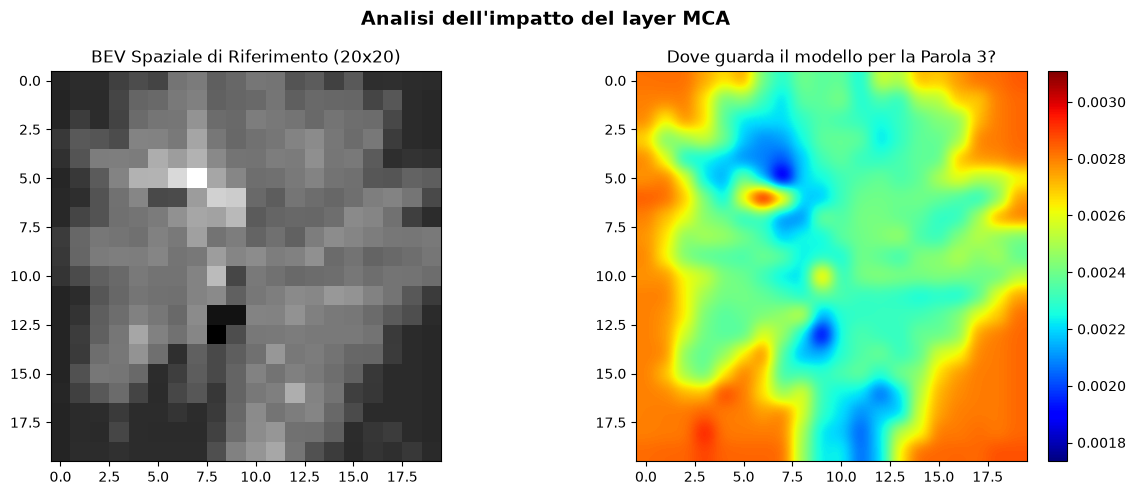

In [21]:
# Scegliamo una parola della domanda che pensiamo sia importante (es. l'indice 5)
indice_parola = 3

# Estraiamo l'attenzione che la parola 5 dà a tutti i 400 token della BEV
attenzione_parola = attn_singolo[indice_parola, :] # Shape: (400,)

# Ritrasformiamo i 400 punti nella griglia spaziale 20x20
mappa_attenzione_spaziale = attenzione_parola.reshape(20, 20)

# =====================================================================
# VISUALIZZAZIONE 2: Sovrapposizione dell'Attenzione sulla BEV
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. La BEV ridotta (giusto per riferimento)
axes[0].imshow(feat_output[0].detach().cpu().numpy().mean(axis=-1).reshape(20, 20), cmap='gray')
axes[0].set_title("BEV Spaziale di Riferimento (20x20)")

# 2. La mappa di calore dell'attenzione della parola selezionata
im = axes[1].imshow(mappa_attenzione_spaziale, cmap='jet', interpolation='gaussian')
axes[1].set_title(f"Dove guarda il modello per la Parola {indice_parola}?")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Analisi dell'impatto del layer MCA", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### HEAD

In [18]:
head = OutputHead()
out = head(text_out)
print(out.shape) # [4,30]

torch.Size([4, 30])


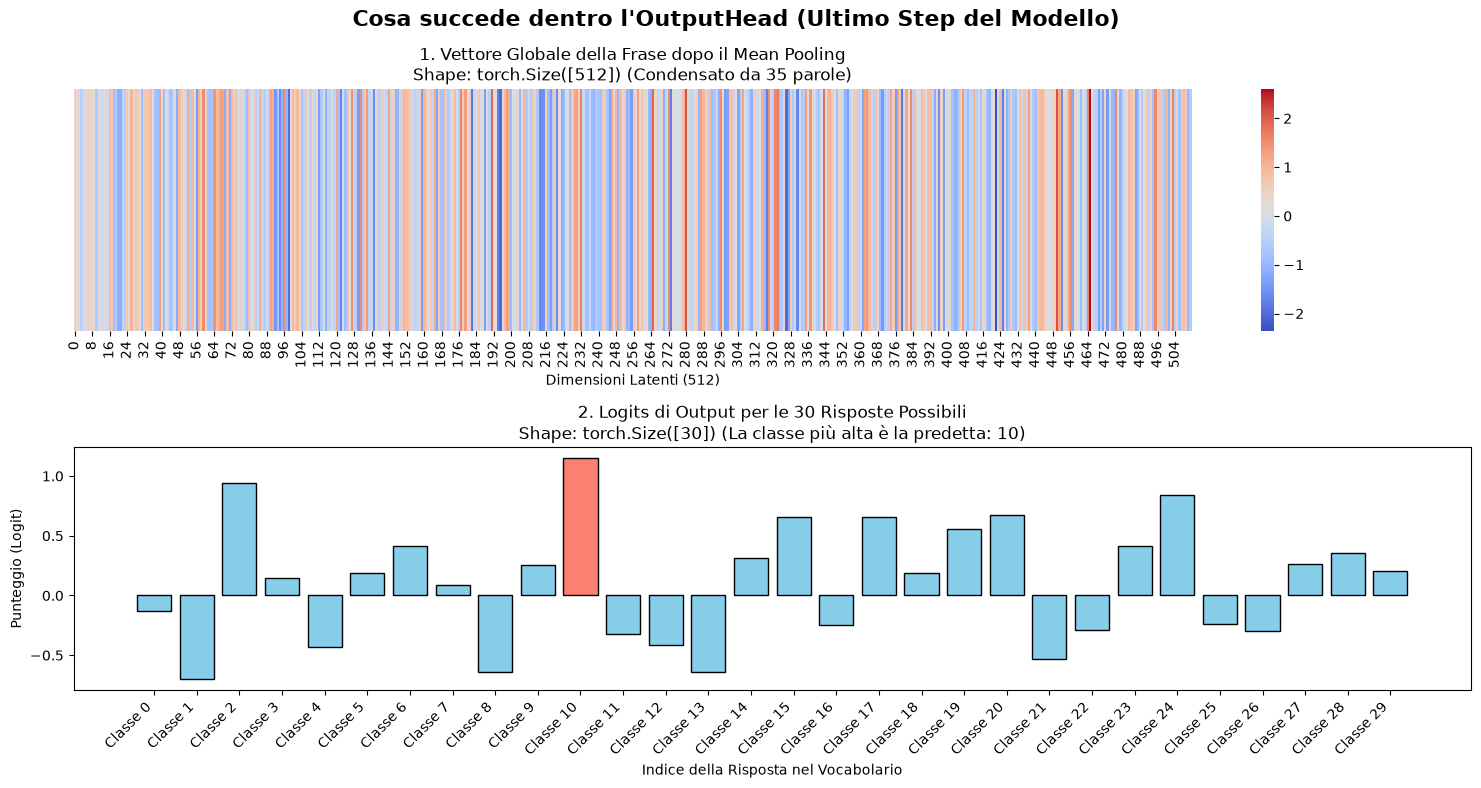

Risposta predetta dal modello (Indice con valore massimo): 10
Risposta corretta del dataset (Target ans[0]): 1


In [24]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Inizializziamo la tua head e calcoliamo l'output
head = OutputHead(d_model=512, num_classes=30)

with torch.no_grad():
    # Passaggio 1: Mean pooling interno
    testo_condensato = text_out.mean(dim=1) # [4, 512]
    # Passaggio 2: Classificazione lineare
    out = head(text_out) # [4, 30]

# Selezioniamo il primo elemento del batch [0] per guardarlo da vicino
vettore_frase = testo_condensato[0].detach().cpu().numpy() # (512,)
logits_risposte = out[0].detach().cpu().numpy() # (30,)

# =====================================================================
# VISUALIZZAZIONE DOPO I PASSAGGI
# =====================================================================
fig = plt.figure(figsize=(15, 8))

# Grafico 1: Il vettore "Riassunto" della frase (512 elementi)
ax1 = plt.subplot(2, 1, 1)
# Lo mostriamo come una striscia 1x512 per far capire che è un singolo vettore row
sns.heatmap(vettore_frase.reshape(1, -1), cmap='coolwarm', ax=ax1, cbar=True, yticklabels=False)
ax1.set_title(f"1. Vettore Globale della Frase dopo il Mean Pooling\nShape: {testo_condensato[0].shape} (Condensato da 35 parole)")
ax1.set_xlabel("Dimensioni Latenti (512)")

# Grafico 2: I Logits delle 30 risposte (Punteggi del modello)
ax2 = plt.subplot(2, 1, 2)
classi = [f"Classe {i}" for i in range(30)]
bars = ax2.bar(classi, logits_risposte, color='skyblue', edgecolor='black')

# Evidenziamo la colonna con il punteggio più alto (la predizione del modello)
indice_predetto = logits_risposte.argmax()
bars[indice_predetto].set_color('salmon')
bars[indice_predetto].set_edgecolor('black')

ax2.set_title(f"2. Logits di Output per le 30 Risposte Possibili\nShape: {out[0].shape} (La classe più alta è la predetta: {indice_predetto})", fontsize=12)
ax2.set_ylabel("Punteggio (Logit)")
ax2.set_xlabel("Indice della Risposta nel Vocabolario")
plt.xticks(rotation=45, ha='right')

plt.suptitle("Cosa succede dentro l'OutputHead (Ultimo Step del Modello)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Stampa di verifica finale
print(f"Risposta predetta dal modello (Indice con valore massimo): {indice_predetto}")
print(f"Risposta corretta del dataset (Target ans[0]): {ans[0].item()}")

### MODEL

In [ ]:
model = BEVQA()
out = model(feat, quest)
print(out.shape) # [4, 30]

torch.Size([4, 30])


### TRAIN

In [22]:
model = BEVQA().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 10

for epoch in range(num_epochs):
    tr_loss, tr_acc = train_epoch(model, train_dataloader, optimizer, criterion, device)
    val_loss, val_acc = val_epoch(model, val_dataloader, criterion, device)
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
              f"Train Loss: {tr_loss:.4f} - Acc: {tr_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} - Acc: {val_acc:.4f}")

Epoch 01/10 | Train Loss: 1.6079 - Acc: 0.4066 | Val Loss: 6.3216 - Acc: 0.0451


KeyboardInterrupt: 